# Data Profiling — Ajuntament Barcelona Tree Inventory

**Purpose:** describe the dataset's shape, distributions, gaps, and anomalies
so we know what we have before building any pipeline on it.

**Input:** `data/arbrat-viari.csv` (street trees) + `data/arbrat-zona.csv`
(park trees), Open Data BCN, 2024-Q4 / 2026-Q1 vintage.

**Output:** findings written into `docs/data-quality-audit.md`, plus
`data/profile-summary.json` machine-readable summary.

**Decision unit reference:** Superilla / 400m grid. The 2x rule requires
data <=200m native — per-tree point coordinates pass trivially.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


## Cell 3 — Load & combine

The Ajuntament publishes street and park tree inventories as separate CSV
files. We tag each with a `source` column and concatenate.

In [2]:
viari = pd.read_csv("data/arbrat-viari.csv", encoding="utf-8", low_memory=False)
zona = pd.read_csv("data/arbrat-zona.csv", encoding="utf-8", low_memory=False)
viari["source"] = "street"
zona["source"] = "park"
df = pd.concat([viari, zona], ignore_index=True)
print(f"Street trees: {len(viari):>7,}")
print(f"Park trees:   {len(zona):>7,}")
print(f"Combined:     {len(df):>7,}  ({len(df.columns)} cols)")
df.head(3)


FileNotFoundError: [Errno 2] No such file or directory: 'data/arbrat-viari.csv'

## Cell 4 — Shape & dtypes

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Cols: {df.shape[1]}")
print()
print(df.dtypes)


Rows: 189,090
Cols: 23

codi                     str
x_etrs89             float64
y_etrs89             float64
latitud              float64
longitud             float64
tipus_element            str
espai_verd               str
adreca                   str
cat_especie_id         int64
cat_nom_cientific        str
cat_nom_castella         str
cat_nom_catala           str
categoria_arbrat         str
data_plantacio           str
tipus_aigua              str
tipus_reg                str
geom                     str
catalogacio              str
codi_barri           float64
nom_barri                str
codi_districte       float64
nom_districte            str
source                   str
dtype: object


## Cell 5 — Missing values

Anything above 20% deserves a note in the audit; anything above 80% is
essentially absent.

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)
missing_pct[missing_pct > 0]


catalogacio         99.51
tipus_aigua         94.03
data_plantacio      81.01
espai_verd          60.40
cat_nom_catala       2.17
cat_nom_castella     1.96
tipus_reg            0.03
categoria_arbrat     0.02
codi_barri           0.01
nom_barri            0.01
dtype: float64

## Cell 6 — Coordinate bounds & district coverage

In [ ]:
print(f"Lat range: {df['latitud'].min():.6f}  ->  {df['latitud'].max():.6f}")
print(f"Lon range: {df['longitud'].min():.6f}  ->  {df['longitud'].max():.6f}")
print()
print("Trees per district:")
print(df["nom_districte"].value_counts().to_string())


Lat range: 41.344797  ->  41.467776
Lon range: 2.088837  ->  2.225044

Trees per district:
nom_districte
SANT MARTÍ               36119
SANTS - MONTJUÏC         23424
EIXAMPLE                 23371
SANT ANDREU              20628
NOU BARRIS               20131
HORTA - GUINARDÓ         19153
LES CORTS                16001
SARRIÀ - SANT GERVASI    15252
GRÀCIA                    8232
CIUTAT VELLA              6773


## Cell 7 — Categorical / ID summary

Low-cardinality fields are useful for filtering; high-cardinality fields
(species name) drive the FungalRoot join.

In [ ]:
for col in ["tipus_element", "categoria_arbrat", "tipus_aigua", "tipus_reg",
            "codi_districte", "cat_nom_cientific", "cat_especie_id"]:
    n = df[col].nunique(dropna=True)
    print(f"  {col:25s}  {n:>5} unique")


  tipus_element                  4 unique
  categoria_arbrat               4 unique
  tipus_aigua                    3 unique
  tipus_reg                      8 unique
  codi_districte                10 unique


  cat_nom_cientific            381 unique
  cat_especie_id               383 unique


## Cell 8 — Species: how many distinct species, and is the taxonomy
consistent enough to join against FungalRoot at species level?

This is the v1 brief's open question. We test for "genus-only" entries
(species names that are just a genus, e.g. *Washingtonia sp*) — if the
fraction is high, we'd have to fall back to genus-level matching.

In [ ]:
def is_genus_only(name):
    if not isinstance(name, str): return None
    n = name.strip()
    if " sp." in n or n.endswith(" sp"): return True
    parts = n.replace("×", " ").split()
    parts = [p for p in parts if p and p != "x" and p != "×"]
    return len(parts) < 2

df["_genus_only"] = df["cat_nom_cientific"].apply(is_genus_only)
total = df["cat_nom_cientific"].notna().sum()
n_genus = int(df["_genus_only"].sum())
n_missing = int(df["cat_nom_cientific"].isna().sum())
print(f"Total non-null species names:  {total:,}")
print(f"Genus-only entries:            {n_genus:,}  ({n_genus/total*100:.2f}%)")
print(f"Missing species names:         {n_missing:,}")
print()
print("Genus-only examples (top 10):")
print(df[df["_genus_only"]==True]["cat_nom_cientific"].value_counts().head(10).to_string())


Total non-null species names:  189,090
Genus-only entries:            25  (0.01%)
Missing species names:         0

Genus-only examples (top 10):
cat_nom_cientific
Washingtonia sp    25


## Cell 9 — Top species composition

Are most trees AM-host genera (*Platanus*, *Tilia*, *Celtis*, *Citrus*,
*Melia*) — in which case AM-blindness is a major limit on what GBIF can
tell us — or do EM-host genera (*Quercus*, *Pinus*) provide a meaningful
subset where the observation layer can do useful work?

In [ ]:
top20 = df["cat_nom_cientific"].value_counts().head(20)
top20


cat_nom_cientific
Platanus × acerifolia             42828
Celtis australis                  21304
Tipuana tipu                      10748
Styphnolobium japonicum            9931
Melia azedarach                    7248
Brachychiton populneus             6323
Jacaranda mimosifolia              4916
Pinus pinea                        4287
Ligustrum lucidum                  4252
Pyrus calleryana 'Chanticleer'     3707
Ulmus pumila                       3676
Cercis siliquastrum                3550
Prunus cerasifera 'Pissardii'      3439
Cupressus sempervirens             2909
Citrus × aurantium                 2828
Robinia pseudoacacia               2824
Pinus halepensis                   2549
Quercus ilex                       2307
Magnolia grandiflora               2153
Grevillea robusta                  2134
Name: count, dtype: int64

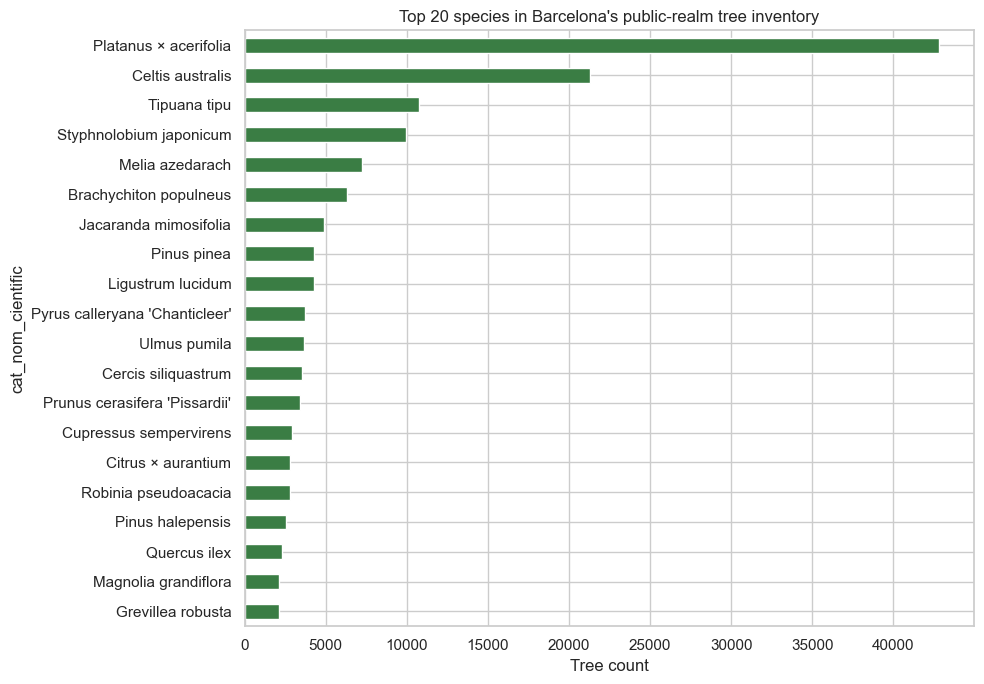

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
top20[::-1].plot(kind="barh", ax=ax, color="#3a7d44")
ax.set_xlabel("Tree count")
ax.set_title("Top 20 species in Barcelona's public-realm tree inventory")
plt.tight_layout()
plt.show()


## Cell 10 — Planting date completeness + temporal coverage

How much of the inventory has a known planting date? What's the span?
Anomalies (future dates, pre-1900) flagged.

In [ ]:
df["data_plantacio_dt"] = pd.to_datetime(df["data_plantacio"], errors="coerce")
total_pd = df["data_plantacio"].notna().sum()
valid_pd = df["data_plantacio_dt"].notna().sum()
missing_pd = df["data_plantacio"].isna().sum()
print(f"Records WITH planting date string:    {total_pd:,}")
print(f"  parseable as date:                  {valid_pd:,}")
print(f"  unparseable (kept null):            {total_pd - valid_pd:,}")
print(f"Records WITHOUT planting date string: {missing_pd:,}  ({missing_pd/len(df)*100:.1f}%)")
known = df["data_plantacio_dt"].dropna()
if len(known):
    print(f"Date range (parsed):  {known.min()}  ->  {known.max()}")
    future = (df["data_plantacio_dt"] > pd.Timestamp.now()).sum()
    pre_1900 = ((df["data_plantacio_dt"] < pd.Timestamp("1900-01-01"))
                & df["data_plantacio_dt"].notna()).sum()
    print(f"  Future-dated entries:   {int(future)}")
    print(f"  Pre-1900 entries:       {int(pre_1900)}")


Records WITH planting date string:    35,914
  parseable as date:                  35,914
  unparseable (kept null):            0
Records WITHOUT planting date string: 153,176  (81.0%)
Date range (parsed):  0013-04-22 00:00:00  ->  2026-09-30 00:00:00
  Future-dated entries:   28
  Pre-1900 entries:       8


## Cell 11 — Tree count by district

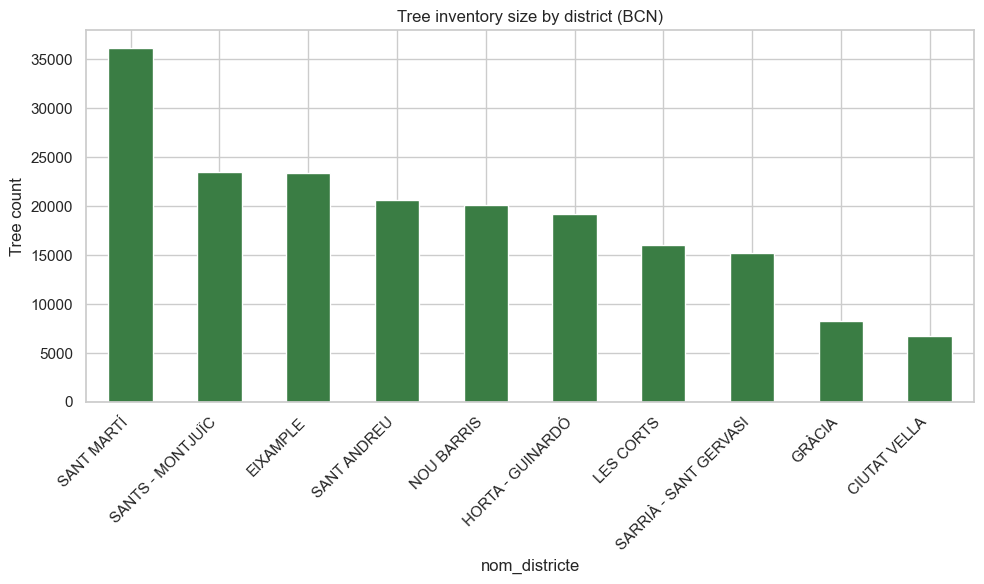

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = df["nom_districte"].value_counts()
counts.plot(kind="bar", ax=ax, color="#3a7d44")
ax.set_ylabel("Tree count")
ax.set_title("Tree inventory size by district (BCN)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Cell 12 — Anomaly hunt

In [ ]:
anomalies = []

bbox_oob = df[((df["latitud"] < 41.30) | (df["latitud"] > 41.50) |
               (df["longitud"] < 2.04) | (df["longitud"] > 2.24)) &
              df["latitud"].notna()]
anomalies.append(("coords outside BCN bbox", len(bbox_oob)))

bad_dist = df[df["codi_districte"].isna() | (df["codi_districte"].astype(str) == "99")]
anomalies.append(("missing/invalid district", len(bad_dist)))

anomalies.append(("duplicate codi", int(df["codi"].duplicated().sum())))

bad_id = df[(df["cat_especie_id"].astype(str).str.isnumeric()) &
            (pd.to_numeric(df["cat_especie_id"], errors="coerce") <= 0)]
anomalies.append(("species_id <= 0", len(bad_id)))

future = (df["data_plantacio_dt"] > pd.Timestamp.now()).sum()
anomalies.append(("future plantation dates", int(future)))

pre1900 = ((df["data_plantacio_dt"] < pd.Timestamp("1900-01-01"))
           & df["data_plantacio_dt"].notna()).sum()
anomalies.append(("pre-1900 plantation dates", int(pre1900)))

anom_df = pd.DataFrame(anomalies, columns=["anomaly", "count"])
print(anom_df.to_string(index=False))


                  anomaly  count
  coords outside BCN bbox      0
 missing/invalid district      6
           duplicate codi      0
          species_id <= 0      0
  future plantation dates     28
pre-1900 plantation dates      8


## Cell 13 — Three things profiling revealed

1. **Species-level taxonomy is consistent.** Only ~25 records (0.01%) are
   genus-only — all *Washingtonia sp*. The v1 brief's worry that we'd be
   forced to fall back to genus-level FungalRoot matching is unfounded;
   species-level join is feasible.

2. **AM-host dominance confirmed empirically.** The top six species
   (*Platanus x acerifolia*, *Celtis australis*, *Tipuana tipu*,
   *Styphnolobium japonicum*, *Melia azedarach*, *Brachychiton populneus*)
   are AM hosts. EM-host taxa (*Pinus pinea*, *Pinus halepensis*,
   *Quercus ilex*, ~9k trees combined) appear at meaningful counts so
   the observed layer can still do useful work for the EM-dominant
   subset, but the dominant signal is AM and therefore not
   citizen-science-visible — the AM-blindness limit is foundational, not
   a footnote.

3. **Planting dates are mostly missing.** ~81% of records carry no
   planting date. Snapshot-state analysis only; do not attempt
   change-detection without comparing two snapshots.

**Implications for the brief:** v1 brief's "consistent species-level
taxonomy" open question is **resolved YES**. v2 brief is updated to
reflect.

**Implications for the pipeline (Session 3):** species-level FungalRoot
join is feasible; treat genus-only entries (~25) as a documented dropout.
Planting-date analyses are out of scope at inventory level.


## Cell 14 — Save profile summary

In [ ]:
profile_summary = {
    "dataset": "Ajuntament BCN tree inventory (street + park combined)",
    "rows_street": int(len(viari)),
    "rows_park": int(len(zona)),
    "rows_combined": int(len(df)),
    "columns": int(len(df.columns)),
    "missing_pct": {col: float(frac) for col, frac in missing.items() if frac > 0},
    "coord_bounds": {
        "lat_min": float(df["latitud"].min()),
        "lat_max": float(df["latitud"].max()),
        "lon_min": float(df["longitud"].min()),
        "lon_max": float(df["longitud"].max()),
    },
    "unique_species": int(df["cat_nom_cientific"].nunique()),
    "unique_districts": int(df["nom_districte"].nunique()),
    "trees_per_district": df["nom_districte"].value_counts().to_dict(),
    "top_20_species": top20.to_dict(),
    "genus_only_count": int(n_genus),
    "genus_only_pct": float(n_genus / total * 100),
    "anomalies": dict(anomalies),
    "planting_date_missing_pct": float(df["data_plantacio"].isna().mean()),
}
with open("data/profile-summary.json", "w", encoding="utf-8") as f:
    json.dump(profile_summary, f, indent=2, default=str, ensure_ascii=False)
print("Saved data/profile-summary.json")


Saved data/profile-summary.json
